<a href="https://colab.research.google.com/github/Karimmaniyar44/Credit_Card_Analytics_Dashboard./blob/main/Movie_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv(r"https://raw.githubusercontent.com/YBIFoundation/Dataset/refs/heads/main/Movies%20Recommendation.csv")

In [4]:
df.head()

,Movie_ID,Movie_Title,Movie_Genre,Movie_Language,Movie_Budget,Movie_Popularity,Movie_Release_Date,Movie_Revenue,Movie_Runtime,Movie_Vote,...,Movie_Homepage,Movie_Keywords,Movie_Overview,Movie_Production_House,Movie_Production_Country,Movie_Spoken_Language,Movie_Tagline,Movie_Cast,Movie_Crew,Movie_Director
0,1,Four Rooms,Crime Comedy,en,4000000,22.876230,09-12-1995,4300000,98.0,6.5,...,NaN,hotel new year's eve witch bet hotel room,It's Ted the Bellhop's first night on the job....,"[{""name"": ""Miramax Films"", ""id"": 14}, {""name"":...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]",Twelve outrageous guests. Four scandalous requ...,Tim Roth Antonio Banderas Jennifer Beals Madon...,"[{'name': 'Allison Anders', 'gender': 1, 'depa...",Allison Anders
1,2,Star Wars,Adventure Action Science Fiction,en,11000000,126.393695,25-05-1977,775398007,121.0,8.1,...,http://www.starwars.com/films/star-wars-episod...,android galaxy hermit death star lightsaber,Princess Leia is captured and held hostage by ...,"[{""name"": ""Lucasfilm"", ""id"": 1}, {""name"": ""Twe...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]","A long time ago in a galaxy far, far away...",Mark Hamill Harrison Ford Carrie Fisher Peter ...,"[{'name': 'George Lucas', 'gender': 2, 'depart...",George Lucas
2,3,Finding Nemo,Animation Family,en,94000000,85.688789,30-05-2003,940335536,100.0,7.6,...,http://movies.disney.com/finding-nemo,father son relationship harbor underwater fish...,"Nemo, an adventurous young clownfish, is unexp...","[{""name"": ""Pixar Animation Studios"", ""id"": 3}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]","There are 3.7 trillion fish in the ocean, they...",Albert Brooks Ellen DeGeneres Alexander Gould ...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton
3,4,Forrest Gump,Comedy Drama Romance,en,55000000,138.133331,06-07-1994,677945399,142.0,8.2,...,NaN,vietnam veteran hippie mentally disabled runni...,A man with a low IQ has accomplished great thi...,"[{""name"": ""Paramount Pictures"", ""id"": 4}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]","The world will never be the same, once you've ...",Tom Hanks Robin Wright Gary Sinise Mykelti Wil...,"[{'name': 'Alan Silvestri', 'gender': 2, 'depa...",Robert Zemeckis
4,5,American Beauty,Drama,en,15000000,80.878605,15-09-1999,356296601,122.0,7.9,...,http://www.dreamworks.com/ab/,male nudity female nudity adultery midlife cri...,"Lester Burnham, a depressed suburban father in...","[{""name"": ""DreamWorks SKG"", ""id"": 27}, {""name""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]",Look closer.,Kevin Spacey Annette Bening Thora Birch Wes Be...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4760 entries, 0 to 4759
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Movie_ID                  4760 non-null   int64  
 1   Movie_Title               4760 non-null   object 
 2   Movie_Genre               4760 non-null   object 
 3   Movie_Language            4760 non-null   object 
 4   Movie_Budget              4760 non-null   int64  
 5   Movie_Popularity          4760 non-null   float64
 6   Movie_Release_Date        4760 non-null   object 
 7   Movie_Revenue             4760 non-null   int64  
 8   Movie_Runtime             4758 non-null   float64
 9   Movie_Vote                4760 non-null   float64
 10  Movie_Vote_Count          4760 non-null   int64  
 11  Movie_Homepage            1699 non-null   object 
 12  Movie_Keywords            4373 non-null   object 
 13  Movie_Overview            4757 non-null   object 
 14  Movie_Pr

In [6]:
df.shape

(4760, 21)

In [7]:
df.columns

Index(['Movie_ID', 'Movie_Title', 'Movie_Genre', 'Movie_Language',
       'Movie_Budget', 'Movie_Popularity', 'Movie_Release_Date',
       'Movie_Revenue', 'Movie_Runtime', 'Movie_Vote', 'Movie_Vote_Count',
       'Movie_Homepage', 'Movie_Keywords', 'Movie_Overview',
       'Movie_Production_House', 'Movie_Production_Country',
       'Movie_Spoken_Language', 'Movie_Tagline', 'Movie_Cast', 'Movie_Crew',
       'Movie_Director'],
      dtype='object')

In [8]:
df_features = df[['Movie_Genre','Movie_Keywords','Movie_Tagline','Movie_Cast','Movie_Director']].fillna('')

In [9]:
df_features.shape

(4760, 5)

In [10]:
df_features

,Movie_Genre,Movie_Keywords,Movie_Tagline,Movie_Cast,Movie_Director
0,Crime Comedy,hotel new year's eve witch bet hotel room,Twelve outrageous guests. Four scandalous requ...,Tim Roth Antonio Banderas Jennifer Beals Madon...,Allison Anders
1,Adventure Action Science Fiction,android galaxy hermit death star lightsaber,"A long time ago in a galaxy far, far away...",Mark Hamill Harrison Ford Carrie Fisher Peter ...,George Lucas
2,Animation Family,father son relationship harbor underwater fish...,"There are 3.7 trillion fish in the ocean, they...",Albert Brooks Ellen DeGeneres Alexander Gould ...,Andrew Stanton
3,Comedy Drama Romance,vietnam veteran hippie mentally disabled runni...,"The world will never be the same, once you've ...",Tom Hanks Robin Wright Gary Sinise Mykelti Wil...,Robert Zemeckis
4,Drama,male nudity female nudity adultery midlife cri...,Look closer.,Kevin Spacey Annette Bening Thora Birch Wes Be...,Sam Mendes
...,...,...,...,...,...
4755,Horror,,The hot spot where Satan's waitin'.,Lisa Hart Carroll Michael Des Barres Paul Drak...,Pece Dingo
4756,Comedy Family Drama,,It’s better to stand out than to fit in.,Roni Akurati Brighton Sharbino Jason Lee Anjul...,Frank Lotito
4757,Thriller Drama,christian film sex trafficking,She never knew it could happen to her...,Nicole Smolen Kim Baldwin Ariana Stephens Brys...,Jaco Booyens
4758,Family,,,,


In [11]:
X = df_features['Movie_Genre'] + ' ' + df_features['Movie_Keywords'] + ' ' + df_features['Movie_Tagline'] + ' ' + df_features['Movie_Cast'] + ' ' + df_features['Movie_Director']

In [12]:
X.shape

(4760,)

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [14]:
tfidf = TfidfVectorizer()

In [15]:
X = tfidf.fit_transform(X)

In [16]:
X.shape

(4760, 17258)

In [41]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 123666 stored elements and shape (4760, 17258)>
  Coords	Values
  (0, 3583)	0.06486754376295062
  (0, 3240)	0.04527089872278055
  (0, 7213)	0.25146675849405775
  (0, 10898)	0.17625708810661284
  (0, 17052)	0.26079573581490934
  (0, 5059)	0.29553419178998613
  (0, 16862)	0.12768803549311025
  (0, 1595)	0.15687561633854538
  (0, 13052)	0.1465525095337543
  (0, 15708)	0.17654247479915475
  (0, 11362)	0.18801785343006192
  (0, 6463)	0.18801785343006192
  (0, 5662)	0.1465525095337543
  (0, 13467)	0.19712637387361423
  (0, 12731)	0.19712637387361423
  (0, 614)	0.07642616241686973
  (0, 11244)	0.08262965296941757
  (0, 9206)	0.15186283580984414
  (0, 1495)	0.19712637387361423
  (0, 7454)	0.14745635785412262
  (0, 7071)	0.19822417598406614
  (0, 5499)	0.11454057510303811
  (0, 3878)	0.11998399582562203
  (0, 11242)	0.07277788238484746
  (0, 15219)	0.09800472886453934
  :	:
  (4757, 3485)	0.199161573117024
  (4757, 1184)	0.1889072672

In [18]:
from sklearn.metrics.pairwise import cosine_similarity

In [19]:
Similarity_Score = cosine_similarity(X)

In [20]:
Similarity_Score

array([[1.        , 0.01351235, 0.03570468, ..., 0.        , 0.        ,
        0.        ],
       [0.01351235, 1.        , 0.00806674, ..., 0.        , 0.        ,
        0.        ],
       [0.03570468, 0.00806674, 1.        , ..., 0.        , 0.08014876,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 1.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.08014876, ..., 0.        , 1.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        1.        ]])

In [21]:
Similarity_Score.shape

(4760, 4760)

In [22]:
Favorite_Movie_Name = input('Enter your favorite movie name: ')

Enter your favorite movie name: The Real Jackpot


In [23]:
All_Movies_Name = df['Movie_Title'].tolist()

In [24]:
import difflib

In [26]:
Movie_Recommendation = difflib.get_close_matches(Favorite_Movie_Name, All_Movies_Name)
print(Movie_Recommendation)

['The Real Cancun', 'The Jacket', 'The Relic']


In [27]:
Close_Match = Movie_Recommendation[0]
print(Close_Match)

The Real Cancun


In [28]:
Index_of_a_Close_Match_Movie = df[df.Movie_Title == Close_Match]['Movie_ID'].values[0]
print(Index_of_a_Close_Match_Movie)

2659


In [29]:
Recommendation_Score = list(enumerate(Similarity_Score[Index_of_a_Close_Match_Movie]))
print(Recommendation_Score)

[(0, np.float64(0.004107914459569808)), (1, np.float64(0.007335284184652207)), (2, np.float64(0.0)), (3, np.float64(0.005025162960785075)), (4, np.float64(0.0)), (5, np.float64(0.0)), (6, np.float64(0.00883591875072727)), (7, np.float64(0.0)), (8, np.float64(0.0)), (9, np.float64(0.007599778904368191)), (10, np.float64(0.008751750119850143)), (11, np.float64(0.0)), (12, np.float64(0.0)), (13, np.float64(0.0)), (14, np.float64(0.0052306519149550494)), (15, np.float64(0.0)), (16, np.float64(0.0)), (17, np.float64(0.008723716426461393)), (18, np.float64(0.0)), (19, np.float64(0.0)), (20, np.float64(0.0)), (21, np.float64(0.0)), (22, np.float64(0.0376892053956322)), (23, np.float64(0.0)), (24, np.float64(0.0)), (25, np.float64(0.004728438229881369)), (26, np.float64(0.0)), (27, np.float64(0.0)), (28, np.float64(0.005803709252037202)), (29, np.float64(0.0)), (30, np.float64(0.0)), (31, np.float64(0.0)), (32, np.float64(0.007201771057818649)), (33, np.float64(0.0)), (34, np.float64(0.0)), (3

In [30]:
Sorted_Similar_Movie = sorted(Recommendation_Score, key = lambda x:x[1], reverse = True)
print(Sorted_Similar_Movie)

[(2659, np.float64(1.0)), (929, np.float64(0.3201385735876731)), (2889, np.float64(0.29587197253124625)), (3762, np.float64(0.23732078548590113)), (4384, np.float64(0.20163991044367208)), (241, np.float64(0.18171566376736253)), (1110, np.float64(0.17905471480827917)), (1046, np.float64(0.16169785212994248)), (1569, np.float64(0.15255587508511814)), (971, np.float64(0.1356303082926795)), (153, np.float64(0.13277594804231452)), (3352, np.float64(0.13221299499306963)), (2894, np.float64(0.12935468964346075)), (2816, np.float64(0.1253825366908552)), (1532, np.float64(0.12507804468136638)), (4085, np.float64(0.11997327396748274)), (2420, np.float64(0.11734196108635225)), (528, np.float64(0.11659320096773901)), (3855, np.float64(0.11180713757361829)), (2556, np.float64(0.11037228595938921)), (2890, np.float64(0.10949965061939787)), (2311, np.float64(0.10642491249552374)), (188, np.float64(0.10560029556385439)), (1657, np.float64(0.09494987414191583)), (1501, np.float64(0.09447325896484922)),

In [31]:
print("Top Movies suggested for you ...")
i=1
for movie in Sorted_Similar_Movie:
  index = movie[0]
  title_from_index = df[df.index == index]['Movie_Title'].values[0]
  if (i<31):
    print(i, '.', title_from_index)
    i +=1

Top Movies suggested for you ...
1 . The Hebrew Hammer
2 . Sweet Sweetback's Baadasssss Song
3 . I Love Your Work
4 . Redemption Road
5 . Red Sky
6 . Jaws: The Revenge
7 . Ali
8 . Highlander: The Final Dimension
9 . 13 Going on 30
10 . 27 Dresses
11 . Inspector Gadget
12 . Barry Munday
13 . Love Happens
14 . Whipped
15 . Cursed
16 . Carrie
17 . Blonde Ambition
18 . Night at the Museum
19 . Jeff, Who Lives at Home
20 . Character
21 . Raising Victor Vargas
22 . The Hammer
23 . Mary Poppins
24 . Universal Soldier: The Return
25 . How to Lose a Guy in 10 Days
26 . Celebrity
27 . Happily N'Ever After
28 . Curious George
29 . The Matador
30 . The Valley of Decision


In [37]:
Movie_name = input("Enter your favorite movie name: ")
list_of_all_titles = df['Movie_Title'].tolist()
Find_Clossest_Match = difflib.get_close_matches(Movie_name, list_of_all_titles)
Closest_Match = Find_Clossest_Match[0]
Index_of_a_Close_Match_Movie = df[df.Movie_Title == Closest_Match]['Movie_ID'].values[0]
Recommendation_Score = list(enumerate(Similarity_Score[Index_of_a_Close_Match_Movie]))
Sorted_Similar_Movie = sorted(Recommendation_Score, key = lambda x:x[1], reverse = True)
print("Top 10 Movies suggested for you ...")
i=1
for movie in Sorted_Similar_Movie:
  index = movie[0]
  title_from_index = df[df.index == index]['Movie_Title'].values[0]
  if (i<11):
    print(i, '.', title_from_index)
    i +=1

Enter your favorite movie name: The Real Jackpot
Top 10 Movies suggested for you ...
1 . The Hebrew Hammer
2 . Sweet Sweetback's Baadasssss Song
3 . I Love Your Work
4 . Redemption Road
5 . Red Sky
6 . Jaws: The Revenge
7 . Ali
8 . Highlander: The Final Dimension
9 . 13 Going on 30
10 . 27 Dresses


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

<ipython-input-38-e61261f642e5>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')


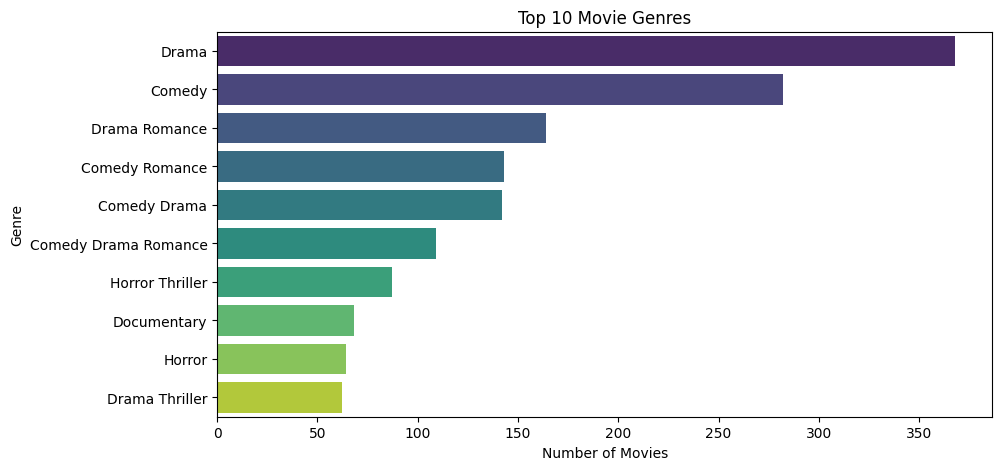

In [38]:
genre_counts = df['Movie_Genre'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')
plt.title('Top 10 Movie Genres')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.show()

<ipython-input-39-61b0561308cf>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=director_counts.values, y=director_counts.index, palette='magma')


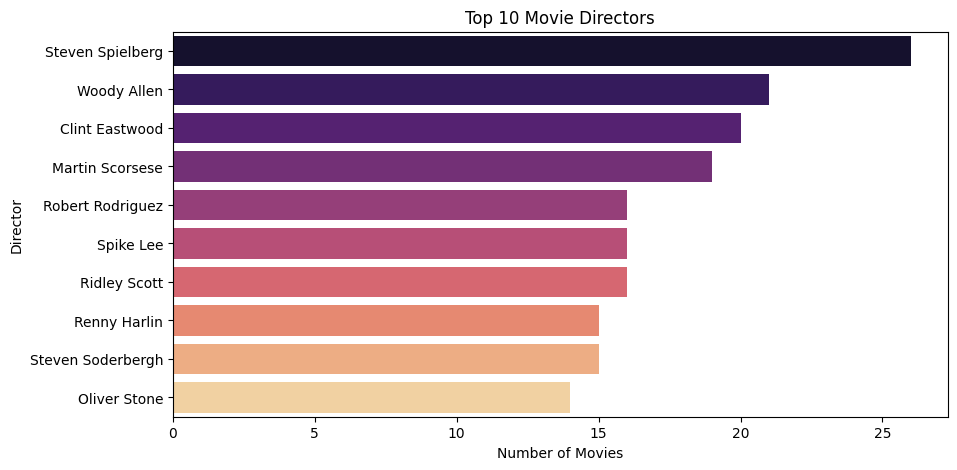

In [39]:
director_counts = df['Movie_Director'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=director_counts.values, y=director_counts.index, palette='magma')
plt.title('Top 10 Movie Directors')
plt.xlabel('Number of Movies')
plt.ylabel('Director')
plt.show()

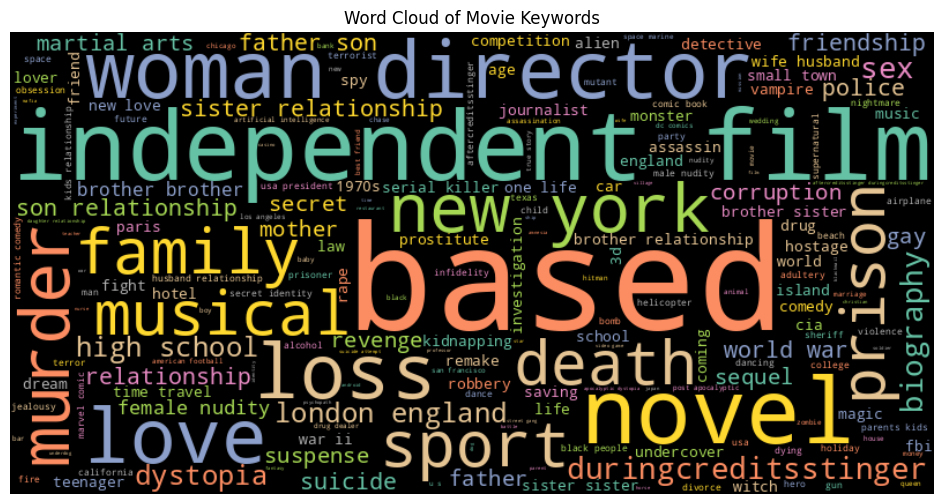

In [40]:
keywords = ' '.join(df['Movie_Keywords'].dropna().astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='black', colormap='Set2').generate(keywords)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Movie Keywords')
plt.show()

<ipython-input-42-1e118b96c641>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(top_cast.values()), y=list(top_cast.keys()), palette='cubehelix')


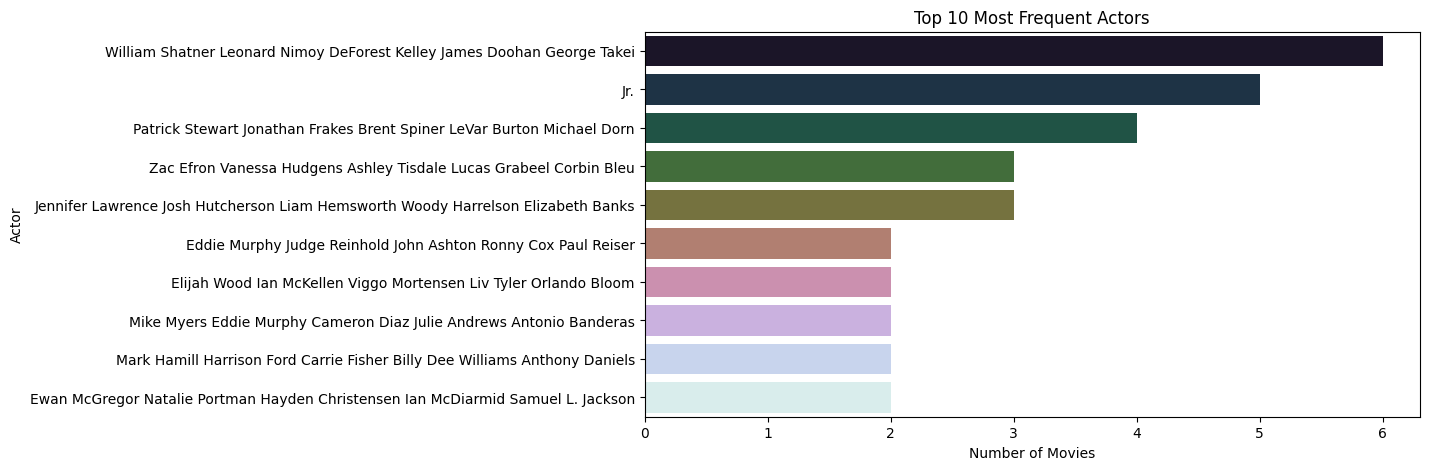

In [42]:
# Top actors (splitting multiple names)
from collections import Counter

cast_series = df['Movie_Cast'].dropna().astype(str).str.split(',')
flat_cast = [actor.strip() for sublist in cast_series for actor in sublist]
cast_counts = Counter(flat_cast)
top_cast = dict(Counter(flat_cast).most_common(10))

plt.figure(figsize=(10,5))
sns.barplot(x=list(top_cast.values()), y=list(top_cast.keys()), palette='cubehelix')
plt.title('Top 10 Most Frequent Actors')
plt.xlabel('Number of Movies')
plt.ylabel('Actor')
plt.show()

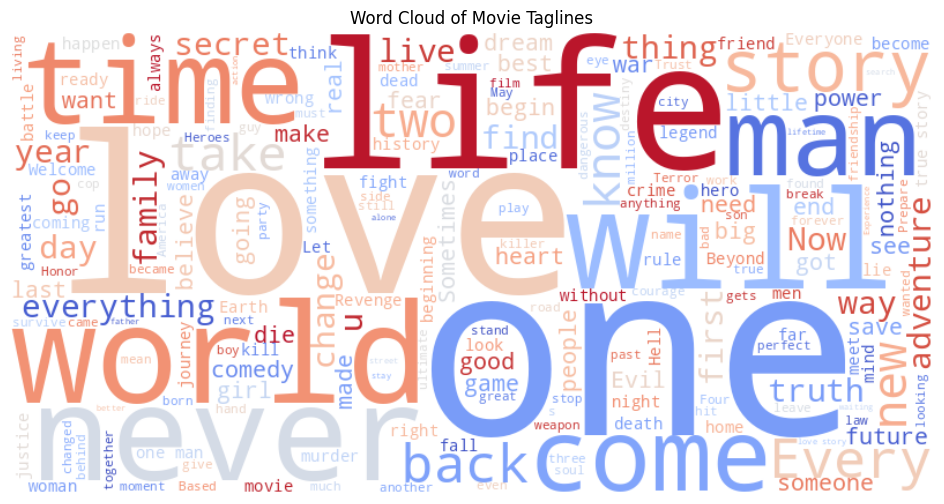

In [43]:
taglines = ' '.join(df['Movie_Tagline'].dropna().astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='coolwarm').generate(taglines)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Movie Taglines')
plt.show()


<ipython-input-44-d919ddfa1a1e>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_data.values, y=missing_data.index, palette='Reds_r')


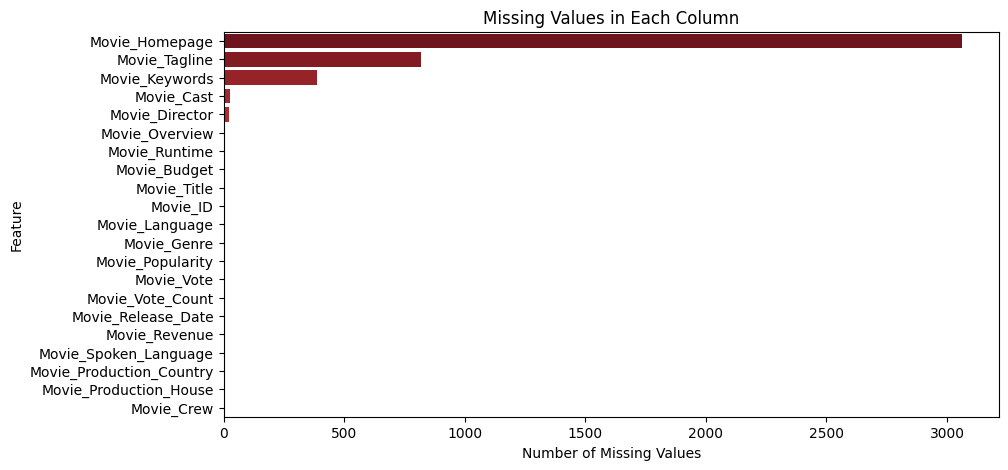

In [44]:
missing_data = df.isnull().sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=missing_data.values, y=missing_data.index, palette='Reds_r')
plt.title('Missing Values in Each Column')
plt.xlabel('Number of Missing Values')
plt.ylabel('Feature')
plt.show()

<ipython-input-45-905e2a165c13>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique_counts.values, y=unique_counts.index, palette='Blues')


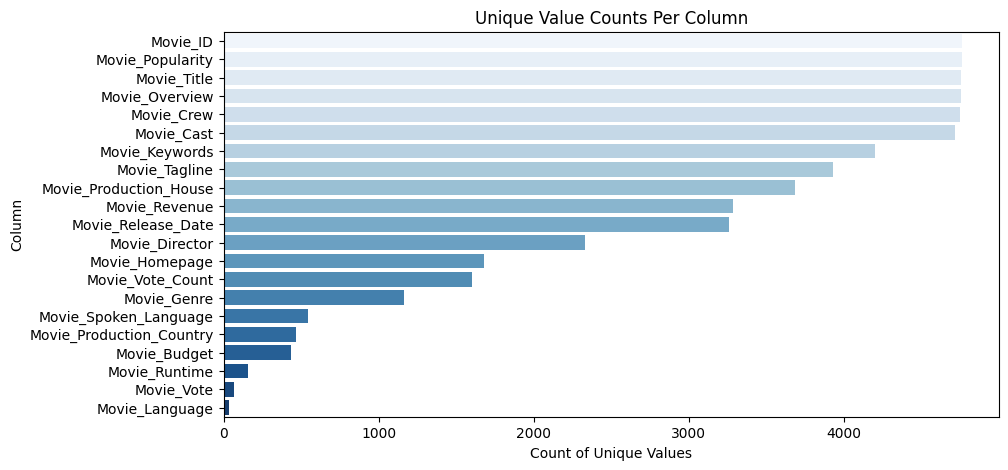

In [45]:
unique_counts = df.nunique().sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=unique_counts.values, y=unique_counts.index, palette='Blues')
plt.title('Unique Value Counts Per Column')
plt.xlabel('Count of Unique Values')
plt.ylabel('Column')
plt.show()

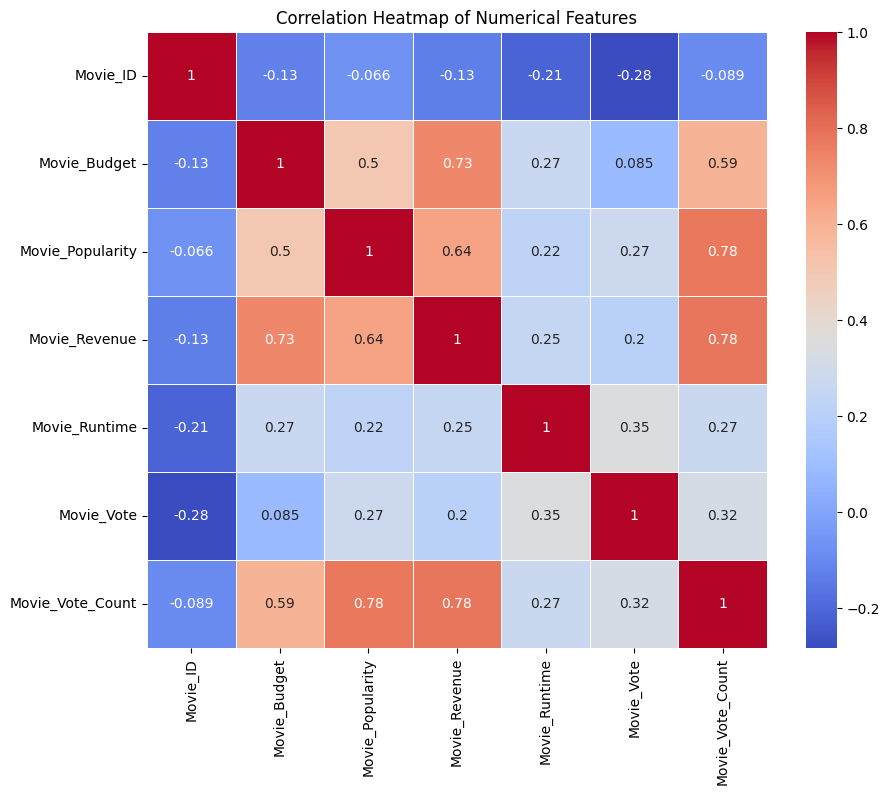

In [46]:
# Filter numerical columns
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()